In [1]:
pip install mediapipe opencv-python torch torchvision tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 96.0 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 94.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.7 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
dopamine-rl 4.1.2 require

In [20]:
import os
import json
import cv2
#import mediapipe as mp
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Step 1: Organize Dataset and Labels
dataset_root = '/kaggle/input/datasets/yousefdotpy/karsl-502'  # Path to extracted dataset
max_signs = 502  # Use first 10 signs for testing; set to 502 for full
max_frames = 30  # Fixed sequence length

In [22]:
# Real labels from KARSL-502 dataset (502 signs, 1-based IDs)
labels_map = {
    1: '0',
    2: '1',
    3: '2',
    4: '3',
    5: '4',
    6: '5',
    7: '6',
    8: '7',
    9: '8',
    10: '9',
    11: '10',
    12: '20',
    13: '30',
    14: '40',
    15: '50',
    16: '60',
    17: '70',
    18: '80',
    19: '90',
    20: '100',
    21: '200',
    22: '300',
    23: '400',
    24: '500',
    25: '600',
    26: '700',
    27: '800',
    28: '900',
    29: '1000',
    30: '1000000',
    31: '10000000',
    32: 'ا',
    33: 'ب',
    34: 'ت',
    35: 'ث',
    36: 'ج',
    37: 'ح',
    38: 'خ',
    39: 'د',
    40: 'ذ',
    41: 'ر',
    42: 'ز',
    43: 'س',
    44: 'ش',
    45: 'ص',
    46: 'ض',
    47: 'ط',
    48: 'ظ',
    49: 'ع',
    50: 'غ',
    51: 'ف',
    52: 'ق',
    53: 'ك',
    54: 'ل',
    55: 'م',
    56: 'ن',
    57: 'ه',
    58: 'و',
    59: 'ي',
    60: 'ة',
    61: 'أ',
    62: 'ؤ',
    63: 'ئ',
    64: 'ئـ',
    65: 'ء',
    66: 'إ',
    67: 'آ',
    68: 'ى',
    69: 'لا',
    70: 'ال',
    71: 'هيكل عظمي',
    72: 'جمجة',
    73: 'عمود فقري',
    74: 'قفص صدري',
    75: 'جهاز تنفسي',
    76: 'قصبة هوائية',
    77: 'رئتان',
    78: 'شهيق - زفير',
    79: 'جهاز هضمي',
    80: 'وجه',
    81: 'بلعوم',
    82: 'كبد',
    83: 'البنكرياس',
    84: 'الأمعاء الدقيقة',
    85: 'الأمعاء الغليظة',
    86: 'الزائدة الدودية',
    87: 'جهاز عصبي',
    88: 'قلب',
    89: 'حواس خمس',
    90: 'عضلة',
    91: 'أنسجة',
    92: 'مستشفى',
    93: 'إسعافات أولية',
    94: 'جرح نازف',
    95: 'حروق',
    96: 'مخدر/ بنج',
    97: 'عملية جراحية',
    98: 'شاش / ضمادة',
    99: 'شريط لاصق / بلاستر',
    100: 'صيدلية',
    101: 'تحليل دم',
    102: 'فحص سريري',
    103: 'فحص النظر',
    104: 'ميزان حرارة',
    105: 'سماعة أذن',
    106: 'جهاز قياس الضغط',
    107: 'نبض القلب',
    108: 'تحليل طبي',
    109: 'معمل التحاليل / مختبر',
    110: 'صورة اشعة',
    111: 'التهاب',
    112: 'تورم',
    113: 'زكام',
    114: 'عدوى',
    115: 'صداع',
    116: 'ألم',
    117: 'حمى',
    118: 'إسهال',
    119: 'إمساك',
    120: 'مغص',
    121: 'مرض السكر / سكري',
    122: 'أزمة قلبية',
    123: 'سرطان',
    124: 'مرض فقدان المناعة / الإيدز',
    125: 'تساقط الشعر',
    126: 'سكتة قلبية',
    127: 'شلل نصفي',
    128: 'شلل دماغي',
    129: 'ضغط الدم',
    130: 'حساسية',
    131: 'حكة / هرش',
    132: 'دواء',
    133: 'دورة شهرية',
    134: 'مريض / مرض',
    135: 'كبسولة',
    136: 'دواء شراب',
    137: 'مرهم',
    138: 'قطارة',
    139: 'أخذ إبرة',
    140: 'تلقيح',
    141: 'تطعيم',
    142: 'أشعة ليزر',
    143: 'مخدرات',
    144: 'إدمان',
    145: 'توحد / أوتيزم',
    146: 'منغولي',
    147: 'بكتريا',
    148: 'جرثومة',
    149: 'فيروس',
    150: 'إنتشار',
    151: 'إعاقة',
    152: 'إعاقة ذهنية',
    153: 'اعاقة جسدية',
    154: 'اعاقة بصرية',
    155: 'إعاقة سمعية',
    156: 'وباء',
    157: 'مناعة',
    158: 'عصب',
    159: 'معافى',
    160: 'يأكل',
    161: 'يشرب',
    162: 'ينام',
    163: 'يستيقظ',
    164: 'يسمع',
    165: 'يسكت',
    166: 'يشم',
    167: 'يصعد',
    168: 'ينزل',
    169: 'يفتح',
    170: 'يقفل ( يغلق )',
    171: 'يبني',
    172: 'يكسر',
    173: 'يمشي',
    174: 'يحب',
    175: 'يكره',
    176: 'يشوي',
    177: 'يحرث',
    178: 'يزرع',
    179: 'يسقي',
    180: 'يحصد',
    181: 'يفكر',
    182: 'يساعد',
    183: 'يدخن',
    184: 'يدعم',
    185: 'يختار',
    186: 'ينادي',
    187: 'يتنامى',
    188: 'يصبغ',
    189: 'يقف',
    190: 'يستحم',
    191: 'يدخل',
    192: 'أسرة',
    193: 'جدة',
    194: 'جد',
    195: 'أب',
    196: 'أم',
    197: 'أخت',
    198: 'أخ',
    199: 'بنت',
    200: 'رضيع',
    201: 'توأم',
    202: 'رجل',
    203: 'شاب',
    204: 'شابة',
    205: 'حفيد',
    206: 'زواج',
    207: 'حمل',
    208: 'ولادة',
    209: 'عم',
    210: 'عمة',
    211: 'خال',
    212: 'خالة',
    213: 'ابن الأخ',
    214: 'ابن الأخت',
    215: 'ابن العم',
    216: 'ابن',
    217: 'ابنة',
    218: 'ناس',
    219: 'طلاق',
    220: 'خطوبة',
    221: 'حفلة',
    222: 'وفاة',
    223: 'طفل',
    224: 'جميل',
    225: 'قبيح',
    226: 'طويل',
    227: 'قصير',
    228: 'نحيف',
    229: 'سمين',
    230: 'غني',
    231: 'فقير',
    232: 'محبط',
    233: 'مشمئز',
    234: 'مرتبك',
    235: 'قلق',
    236: 'مشوش',
    237: 'خائف',
    238: 'سعيد (مسرور)',
    239: 'حزين',
    240: 'شجاع',
    241: 'جبان',
    242: 'طموح',
    243: 'معجب',
    244: 'غائر من',
    245: 'غائر على',
    246: 'ودود',
    247: 'كريم',
    248: 'بخيل',
    249: 'طماع',
    250: 'كذاب',
    251: 'أناني',
    252: 'متكبر',
    253: 'متواضع',
    254: 'شعور',
    255: 'تعب',
    256: 'بكاء',
    257: 'احتقار',
    258: 'اعتماد على الذات',
    259: 'خفيف',
    260: 'ثقيل',
    261: 'قديم',
    262: 'حسد',
    263: 'صدق',
    264: 'غدر',
    265: 'صبر',
    266: 'لوم',
    267: 'الحق',
    268: 'خيانة',
    269: 'إيثار',
    270: 'تضحية',
    271: 'شفقة',
    272: 'ذكي',
    273: 'أمام',
    274: 'بجانب',
    275: 'بعيد',
    276: 'بين',
    277: 'تحت',
    278: 'حول',
    279: 'خارج',
    280: 'خلف',
    281: 'داخل',
    282: 'فوق',
    283: 'قريب',
    284: 'من خلال',
    285: 'هنا',
    286: 'هناك',
    287: 'يسار',
    288: 'يمين',
    289: 'أهلا وسهلاً',
    290: 'السلام عليكم',
    291: 'تفضل',
    292: 'جار',
    293: 'شكراً',
    294: 'صديق',
    295: 'ضيف',
    296: 'عدو',
    297: 'عيب',
    298: 'هدية',
    299: 'بيت',
    300: 'جدار',
    301: 'سقف',
    302: 'باب',
    303: 'شباك',
    304: 'غرفة',
    305: 'غرفة نوم',
    306: 'سرير',
    307: 'مرتبة سرير ( حشية)',
    308: 'شرشف ( غطاء سرير)',
    309: 'وسادة ( مخدة)',
    310: 'شماعة ( مشجب)',
    311: 'خزانة ملابس',
    312: 'مطبخ',
    313: 'فرن غازي',
    314: 'بوتاغاز (طابخ)',
    315: 'طبق ( صحن)',
    316: 'سكين',
    317: 'شوكة',
    318: 'ملعقة',
    319: 'فنجان',
    320: 'مجمد (فريزر)',
    321: 'كأس ( كوب)',
    322: 'حافظ حرارة ( ترمس)',
    323: 'غرفة طعام',
    324: 'إبريق',
    325: 'طاولة',
    326: 'كنكة ( دلة)',
    327: 'دورة مياه (حمام)',
    328: 'كرسي',
    329: 'غسالة',
    330: 'منشفة',
    331: 'سجادة (زربية)',
    332: 'موكيت ( فرش أرضي) moquette',
    333: 'ثريا (نجفة)',
    334: 'مسجل',
    335: 'شريط كاست',
    336: 'تلفزيون (تلفاز)',
    337: 'طبق هوائي (دش)',
    338: 'شريط فيديو',
    339: 'كاميرا فيديو',
    340: 'كاميرا فوتوغرافية',
    341: 'هاتف ( تلفون)',
    342: 'غرفة ضيوف',
    343: 'فيديو',
    344: 'مبخرة',
    345: 'مدفأة',
    346: 'مفتاح',
    347: 'مروحة',
    348: 'تدفئة مركزية',
    349: 'كهرباء',
    350: 'مكيف',
    351: 'سلك كهربائي',
    352: 'قابس كهربائي ( فيش)',
    353: 'حقيبة سفر',
    354: 'مكواة',
    355: 'ميزان حرارة جوي',
    356: 'الله تعالى',
    357: 'محمد رسول الله',
    358: 'عيسى المسيح',
    359: 'القرآن الكريم',
    360: 'الخلفاء الراشدون',
    361: 'السنة النبوية',
    362: 'أركان الإسلام',
    363: 'أركان الإيمان',
    364: 'الشهادتين',
    365: 'يصلي / الصلاة',
    366: 'الزكاة',
    367: 'الصوم',
    368: 'العمرة',
    369: 'الحج',
    370: 'ملائكة',
    371: 'رسول',
    372: 'يوم القيامة',
    373: 'القضاء والقدر',
    374: 'أركان الصلاة',
    375: 'خير',
    376: 'النية',
    377: 'شر',
    378: 'طهارة',
    379: 'مبطلات الصلاة',
    380: 'تيمم',
    381: 'يتوضأ / وضوء',
    382: 'يؤذن',
    383: 'مسح على الخفين',
    384: 'صلاة الفجر',
    385: 'صلاة الظهر',
    386: 'صلاة العصر',
    387: 'صلاة المغرب',
    388: 'صلاة العشاء',
    389: 'خطبة',
    390: 'خطبة الجمعة',
    391: 'خطيب',
    392: 'خطبة العيد',
    393: 'مسجد',
    394: 'سورة',
    395: 'إمام',
    396: 'سورة الفاتحة',
    397: 'آية',
    398: 'ليلة القدر',
    399: 'عيد',
    400: 'عيد الفطر',
    401: 'عيد الأضحى',
    402: 'إحرام',
    403: 'مكة',
    404: 'الكعبة',
    405: 'المدينة المنورة',
    406: 'منى',
    407: 'جبل عرفات',
    408: 'الصفا والمروة',
    409: 'مزدلفة',
    410: 'رمي الجمرات',
    411: 'طواف',
    412: 'ماء زمزم',
    413: 'الأضحية',
    414: 'فك الإحرام',
    415: 'طواف الوداع',
    416: 'المسجد الأقصى',
    417: 'يسبح',
    418: 'الحمد لله',
    419: 'سبحان الله',
    420: 'إيمان',
    421: 'الشرك بالله',
    422: 'أعوذ بالله',
    423: 'شيطان',
    424: 'جن',
    425: 'الضالون',
    426: 'المغضوب عليهم',
    427: 'صنم',
    428: 'زنى',
    429: 'الجنة',
    430: 'النار',
    431: 'روح',
    432: 'حقوق',
    433: 'واجبات',
    434: 'حسنات',
    435: 'سيئات',
    436: 'حلال',
    437: 'حرام',
    438: 'مغفرة',
    439: 'دين',
    440: 'مسيحي',
    441: 'يهودي',
    442: 'كنيسة',
    443: 'إسراء ومعراج',
    444: 'حواء',
    445: 'آدم',
    446: 'صدقة',
    447: 'نبي',
    448: 'هداية',
    449: 'أمانة',
    450: 'شهيد',
    451: 'حقوق الوالدين',
    452: 'عقوق الوالدين',
    453: 'مسلم',
    454: 'رحمة',
    455: 'عيد رأس السنة',
    456: 'فروض',
    457: 'قبة الصخرة',
    458: 'خلق',
    459: 'مهندس',
    460: 'مصور فوتوغرافي',
    461: 'جزار / قصاب',
    462: 'سائق',
    463: 'صائغ',
    464: 'خادم',
    465: 'رئيس قسم',
    466: 'حداد',
    467: 'لحام كهربائي',
    468: 'مترجم لغة الإشارة',
    469: 'مذيع',
    470: 'مترجم لغات',
    471: 'مدير',
    472: 'سفير',
    473: 'وزير',
    474: 'ملك / سلطان',
    475: 'أمير البلاد / رئيس الجمهورية',
    476: 'شيخ',
    477: 'محافظ / وال',
    478: 'ولي عهد / وكيل وزارة',
    479: 'رئيس مجلس الشعب (النواب)',
    480: 'أمين عام',
    481: 'صحفي',
    482: 'رسام',
    483: 'خياط / تارزي',
    484: 'ضابط',
    485: 'طيار',
    486: 'جندي',
    487: 'حلاق',
    488: 'صباغ',
    489: 'رجل إطفاء / دفاع مدني',
    490: 'نجار',
    491: 'معلم / مدرس',
    492: 'طباخ',
    493: 'فلاح',
    494: 'موظف',
    495: 'أمين صندوق',
    496: 'صيدلي',
    497: 'طبيب',
    498: 'ممرضة',
    499: 'ممرض',
    500: 'محام',
    501: 'انتقال',
    502: 'تعيين',
}

num_classes = min(max_signs, len(labels_map))

In [11]:
import os

frame_counts = []
for root, dirs, files in os.walk(dataset_root):
    jpgs = [f for f in files if f.endswith('.jpg')]
    if jpgs:
        frame_counts.append(len(jpgs))

print(f"Min frames: {min(frame_counts)}")
print(f"Max frames: {max(frame_counts)}")
print(f"Average frames: {sum(frame_counts)/len(frame_counts):.1f}")
#max_frames = int(sum(frame_counts) / len(frame_counts))  # = 41
#max_frames = 45

Min frames: 5
Max frames: 269
Average frames: 40.9


In [24]:
selected_ranges = [
    (1, 6),
    (160, 217),
    (223, 243),
    (273, 294),
    (298, 299),
    (485, 495)
]

def is_selected(sign_id):
    for start, end in selected_ranges:
        if start <= sign_id <= end:
            return True
    return False

In [ ]:
# Collect sequences: Each folder with .jpg files is a sequence (repetition), extract sign_id from path
import re
data = []
for root, dirs, files in os.walk(dataset_root):
    jpg_files = [f for f in files if f.endswith('.jpg') or f.endswith('.c')]
    if jpg_files:
        # Extract sign_id from 4-digit pattern in path
        path_str = ' '.join(root.split(os.sep))
        match = re.search(r'(\d{4})', path_str)
        if match:
            sign_str = match.group(1)
            sign_id = int(sign_str)
            if 1 <= sign_id < max_signs and is_selected(sign_id):
                sequence_path = root
                data.append({
                    'sign_id': sign_id,
                    'sequence_path': sequence_path
                })

df = pd.DataFrame(data)
if df.empty:
    print("Warning: No sequences found! Check dataset_root and structure.")
    print("Sample paths:")
    for root, _, files in os.walk(dataset_root):
        for f in files[:5]:
            print(os.path.join(root, f))
else:
    print(f"Found {len(df)} sequences for {max_signs} signs.")
df.to_csv('karsl_metadata.csv', index=False)


In [25]:
df = pd.read_csv('/kaggle/input/datasets/mariamtobar/karsl-metadata-m/karsl_metadata.csv')
df

,sign_id,sequence_path
0,217,/kaggle/input/karsl-502/02/02/test/0217/03_02_...
1,217,/kaggle/input/karsl-502/02/02/test/0217/03_02_...
2,217,/kaggle/input/karsl-502/02/02/test/0217/03_02_...
3,217,/kaggle/input/karsl-502/02/02/test/0217/03_02_...
4,217,/kaggle/input/karsl-502/02/02/test/0217/03_02_...
...,...,...
18010,299,/kaggle/input/karsl-502/01/01/train/0299/03_01...
18011,299,/kaggle/input/karsl-502/01/01/train/0299/03_01...
18012,299,/kaggle/input/karsl-502/01/01/train/0299/03_01...
18013,299,/kaggle/input/karsl-502/01/01/train/0299/03_01...


In [26]:
if not df.empty:
    train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['sign_id'])
    val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['sign_id'])
else:
    train_df = val_df = test_df = pd.DataFrame()

In [27]:
print("Train:", train_df['sign_id'].value_counts().sort_index())
print("Val:  ", val_df['sign_id'].value_counts().sort_index())
print("Test: ", test_df['sign_id'].value_counts().sort_index())

Train: sign_id
1      120
2      120
3      120
4      121
5      146
      ... 
491    121
492    122
493    121
494    121
495    118
Name: count, Length: 120, dtype: int64
Val:   sign_id
1      15
2      15
3      15
4      15
5      18
       ..
491    15
492    15
493    15
494    15
495    15
Name: count, Length: 120, dtype: int64
Test:  sign_id
1      15
2      15
3      15
4      15
5      19
       ..
491    15
492    15
493    15
494    15
495    15
Name: count, Length: 120, dtype: int64


In [28]:
train_df.to_csv("train_metadata.csv", index=False)
val_df.to_csv("val_metadata.csv", index=False)
test_df.to_csv("test_metadata.csv", index=False)

In [29]:
train_df

,sign_id,sequence_path
7856,234,/kaggle/input/karsl-502/03/03/train/0234/03_03...
15671,178,/kaggle/input/karsl-502/01/01/train/0178/03_01...
13837,163,/kaggle/input/karsl-502/01/01/train/0163/03_01...
233,168,/kaggle/input/karsl-502/02/02/test/0168/03_02_...
9815,216,/kaggle/input/karsl-502/03/03/train/0216/03_03...
...,...,...
15892,286,/kaggle/input/karsl-502/01/01/train/0286/03_01...
16172,229,/kaggle/input/karsl-502/01/01/train/0229/03_01...
5647,494,/kaggle/input/karsl-502/02/02/train/0494/03_02...
15008,278,/kaggle/input/karsl-502/01/01/train/0278/03_01...


In [10]:
'''
# 1. Install specific compatible versions
!pip install mediapipe==0.10.14 numpy==1.26.4 ml-dtypes==0.3.1 --force-reinstall

# 2. Restart the kernel (Mandatory for the changes to take effect)
import os
os._exit(0)
'''
!pip uninstall -y tensorflow tensorflow-cpu
!pip install mediapipe==0.10.14 numpy==1.26.4

Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 55.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 85.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 73.2 MB/s eta 0:00:00:00:01
   ━━━━━

In [ ]:
import os
os._exit(0)

In [11]:
import mediapipe as mp
try:
    print(f"MediaPipe version: {mp.__version__}")
    print(f"NumPy version: {mp.resource_util.np.__version__ if hasattr(mp.resource_util, 'np') else 'Check manually'}")
    mp_holistic = mp.solutions.holistic
    print("Success: mp.solutions.holistic is now available!")
except Exception as e:
    print(f"Error: {e}")

MediaPipe version: 0.10.14
NumPy version: Check manually
Success: mp.solutions.holistic is now available!


In [ ]:
'''
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.14
'''

In [ ]:
'''
import os
os._exit(0)
'''

In [ ]:
import os
import cv2
import mediapipe as mp
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
import time
import gc
import sys

# ==========================
# CONFIG
# ==========================
BATCH_SIZE = 500
NUM_WORKERS = 2
BATCHES_PER_RUN = 5

BASE_SAVE_DIR = "/kaggle/working/processed"
os.makedirs(BASE_SAVE_DIR, exist_ok=True)

LANDMARK_IMG_DIR = os.path.join(BASE_SAVE_DIR, "landmark_examples")
os.makedirs(LANDMARK_IMG_DIR, exist_ok=True)

# ==========================
# UTILS
# ==========================
def format_time(seconds):
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = int(seconds % 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

# ==========================
# MEDIAPIPE
# ==========================
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

print("Warming up MediaPipe models...")
with mp_holistic.Holistic(static_image_mode=True, model_complexity=0) as _:
    pass
print("MediaPipe warm-up done.")

def draw_landmarks_on_image(image, results):
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            image,
            results.left_hand_landmarks,
            mp_holistic.HAND_CONNECTIONS
        )
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            image,
            results.right_hand_landmarks,
            mp_holistic.HAND_CONNECTIONS
        )

# ==========================
# PROCESS SINGLE SEQUENCE
# ==========================
def process_single_row(row_data):
    path, sign_id, seq_index = row_data

    with mp_holistic.Holistic(
        static_image_mode=True,
        model_complexity=0,
        enable_segmentation=False,
        refine_face_landmarks=False
    ) as holistic:

        image_files = sorted([
            os.path.join(path, f)
            for f in os.listdir(path)
            if f.endswith(".jpg")
        ])

        landmarks_seq = []
        example_frame = None
        example_results = None

        for img_path in image_files:
            frame = cv2.imread(img_path)
            if frame is None:
                continue

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(frame_rgb)

            if example_frame is None:
                example_frame = frame.copy()
                example_results = results

            lh = (
                np.array([[lm.x, lm.y, lm.z]
                for lm in results.left_hand_landmarks.landmark]).flatten()
                if results.left_hand_landmarks else np.zeros(63)
            )

            rh = (
                np.array([[lm.x, lm.y, lm.z]
                for lm in results.right_hand_landmarks.landmark]).flatten()
                if results.right_hand_landmarks else np.zeros(63)
            )

            landmarks_seq.append(np.concatenate([lh, rh]))

        return (
            np.array(landmarks_seq, dtype=np.float16),
            sign_id,
            seq_index,
            example_frame,
            example_results
        )

# ==========================
# RESUME LOGIC
# ==========================
def get_existing_batches(output_dir):
    return sorted([
        int(f.split("_")[1].split(".")[0])
        for f in os.listdir(output_dir)
        if f.startswith("batch_") and f.endswith(".npz")
    ])

# ==========================
# MAIN PIPELINE
# ==========================
def run_extraction_with_resume(df, split_name, batch_size=BATCH_SIZE):
    output_dir = os.path.join(BASE_SAVE_DIR, split_name)
    os.makedirs(output_dir, exist_ok=True)

    data = list(zip(df["sequence_path"], df["sign_id"], range(len(df))))
    total_batches = (len(data) + batch_size - 1) // batch_size
    existing_batches = set(get_existing_batches(output_dir))

    print(f"\n Split: {split_name}")
    print(f"Total Sequences: {len(data)} | Total Batches: {total_batches}")

    start_time = time.time()
    processed_this_run = 0

    for batch_id in range(total_batches):

        if batch_id in existing_batches:
            continue

        if processed_this_run >= BATCHES_PER_RUN:
            print("\n Batch limit reached. Restart notebook to continue.")
            sys.exit(0)

        batch_start = time.time()
        start_idx = batch_id * batch_size
        batch_subset = data[start_idx:start_idx + batch_size]

        print(f"\n Processing Batch {batch_id}")

        with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
            results = list(
                tqdm(
                    executor.map(process_single_row, batch_subset),
                    total=len(batch_subset)
                )
            )

        # ==========================
        # SAVE ONE LANDMARK IMAGE PER BATCH
        # ==========================
        ex_idx = np.random.randint(len(results))
        _, ex_sign, _, ex_frame, ex_results = results[ex_idx]

        if ex_frame is not None and ex_results is not None:
            draw_landmarks_on_image(ex_frame, ex_results)
            img_path = os.path.join(
                LANDMARK_IMG_DIR,
                f"batch_{batch_id}_sign_{ex_sign}.jpg"
            )
            cv2.imwrite(img_path, ex_frame)

        X_batch = [r[0] for r in results]
        y_batch = [r[1] for r in results]

        save_path = os.path.join(output_dir, f"batch_{batch_id}.npz")
        np.savez_compressed(
            save_path,
            X=np.array(X_batch, dtype=object),
            y=np.array(y_batch, dtype=np.int16)
        )

        batch_time = time.time() - batch_start
        elapsed = time.time() - start_time

        print(f" Saved: {save_path}")
        print(f" Batch Time: {format_time(batch_time)}")

        processed_this_run += 1
        del results, X_batch, y_batch
        gc.collect()

    print("\n Finished successfully!")

# ==========================
# RUN
# ==========================
run_extraction_with_resume(train_df, "train")
run_extraction_with_resume(val_df, "val")
run_extraction_with_resume(test_df, "test")


In [ ]:

import shutil
import os

source_dir = "/kaggle/working/processed"
zip_path = "/kaggle/working/processed.zip"

# Remove old zip if exists
if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    base_name="/kaggle/working/processed",
    format="zip",
    root_dir=source_dir
)

print(" Zipped successfully:", zip_path)


#   Dataset Loader

In [49]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


#   Sale hand size & Centering & Rotation

In [50]:
def normalize_landmarks(sequence):
    normalized = np.zeros_like(sequence)
    for i, frame in enumerate(sequence):
        lh = frame[:63].reshape(21, 3)
        rh = frame[63:].reshape(21, 3)
        if np.any(lh != 0):
            wrist = lh[0]
            lh = lh - wrist
            scale = np.max(np.abs(lh)) + 1e-6
            lh = lh / scale
        if np.any(rh != 0):
            wrist = rh[0]
            rh = rh - wrist
            scale = np.max(np.abs(rh)) + 1e-6
            rh = rh / scale
        normalized[i] = np.concatenate([lh.flatten(), rh.flatten()])
    return normalized

# Padding function

In [52]:
MAX_FRAMES = 30
FEATURES = 126

def pad_sequence(seq, max_len=MAX_FRAMES):
    if len(seq) >= max_len:
        seq = seq[:max_len]
    else:
        pad = np.zeros((max_len - len(seq), FEATURES))
        seq = np.vstack([seq, pad])
    normalized = normalize_landmarks(seq)
    return normalized  

# Dataset class

In [54]:
class SignDataset(Dataset):
    def __init__(self, split_dir, augment=False):  # ← ضيفي augment
        self.X = []
        self.y = []
        self.augment = augment  # ← ضيفي دي

        for f in sorted(os.listdir(split_dir)):
            if f.endswith(".npz"):
                data = np.load(os.path.join(split_dir, f), allow_pickle=True)
                for seq, label in zip(data["X"], data["y"]):
                    self.X.append(pad_sequence(seq))
                    self.y.append(label)

        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        self.y = torch.tensor(np.array(self.y), dtype=torch.long)

    def augment_sequence(self, x):
        x = x.numpy().copy()

        #  Jitter
        x += np.random.normal(0, 0.01, x.shape)

        # Scale
        scale = np.random.uniform(0.9, 1.1)
        x *= scale

        #  Rotation صغيرة (±15 درجة)
        angle = np.random.uniform(-np.pi/12, np.pi/12)
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        R = np.array([[cos_a, -sin_a], [sin_a, cos_a]])
        for i in range(x.shape[0]):
            lh = x[i, :63].reshape(21, 3)
            rh = x[i, 63:].reshape(21, 3)
            if np.any(lh != 0):
                lh[:, :2] = lh[:, :2] @ R.T
            if np.any(rh != 0):
                rh[:, :2] = rh[:, :2] @ R.T
            x[i] = np.concatenate([lh.flatten(), rh.flatten()])

        return torch.tensor(x, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment:
            x = self.augment_sequence(x)
        return x, self.y[idx]

# Attention layer

In [55]:
import torch.nn as nn

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_out):
        # lstm_out: (B, T, 2H)
        scores = self.attn(lstm_out).squeeze(-1)   # (B, T)
        weights = torch.softmax(scores, dim=1)     # attention weights
        context = torch.sum(lstm_out * weights.unsqueeze(-1), dim=1)
        return context, weights


# Transformer + Attention Pooling Model

In [56]:
class SignLSTM_Attention(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=FEATURES,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.attention = Attention(256)
        self.fc = nn.Linear(256 * 2, num_classes)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        context, attn_weights = self.attention(lstm_out)
        logits = self.fc(context)
        return logits, attn_weights


# DataLoaders

In [57]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# جديد
train_ds = SignDataset("/kaggle/input/datasets/youstenawael/processed/train", augment=True)
val_ds   = SignDataset("/kaggle/input/datasets/youstenawael/processed/val")
test_ds  = SignDataset("/kaggle/input/datasets/youstenawael/processed/test")

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)

model = SignLSTM_Attention(num_classes=502).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [58]:
train_losses = []
val_accuracies = []

for epoch in range(20):
    model.train()
    total_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits, _ = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_losses.append(total_loss)

    # Validation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            logits, _ = model(X)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    val_accuracies.append(acc)

    print(f"Epoch {epoch+1} | Loss: {total_loss:.3f} | Val Acc: {acc:.4f}")


Epoch 1 | Loss: 581.356 | Val Acc: 0.6696
Epoch 2 | Loss: 195.935 | Val Acc: 0.8218
Epoch 3 | Loss: 101.679 | Val Acc: 0.8712
Epoch 4 | Loss: 70.399 | Val Acc: 0.9178
Epoch 5 | Loss: 59.562 | Val Acc: 0.9300
Epoch 6 | Loss: 39.224 | Val Acc: 0.9450
Epoch 7 | Loss: 38.241 | Val Acc: 0.9484
Epoch 8 | Loss: 31.834 | Val Acc: 0.9517
Epoch 9 | Loss: 29.718 | Val Acc: 0.9539
Epoch 10 | Loss: 27.900 | Val Acc: 0.9500
Epoch 11 | Loss: 25.859 | Val Acc: 0.9617
Epoch 12 | Loss: 23.954 | Val Acc: 0.9611
Epoch 13 | Loss: 22.338 | Val Acc: 0.9584
Epoch 14 | Loss: 21.271 | Val Acc: 0.9634
Epoch 15 | Loss: 17.220 | Val Acc: 0.9745
Epoch 16 | Loss: 16.604 | Val Acc: 0.9789
Epoch 17 | Loss: 14.137 | Val Acc: 0.9728
Epoch 18 | Loss: 19.436 | Val Acc: 0.9706
Epoch 19 | Loss: 15.880 | Val Acc: 0.9717
Epoch 20 | Loss: 14.198 | Val Acc: 0.9806


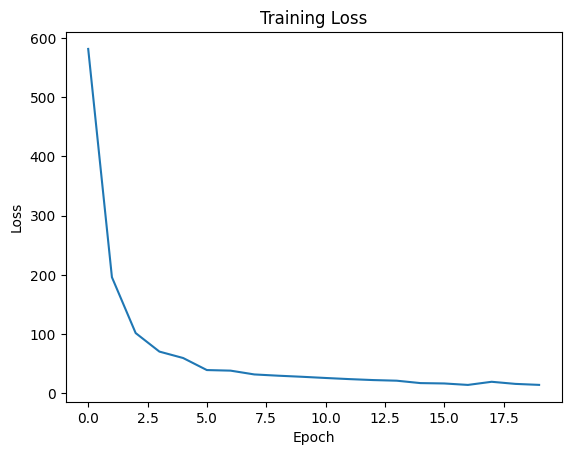

In [59]:
plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


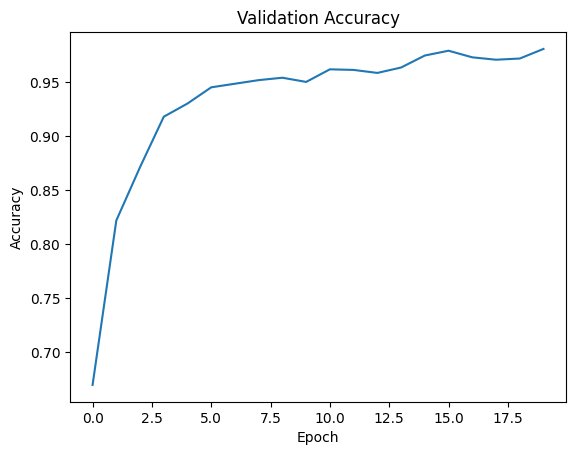

In [60]:
plt.figure()
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


In [62]:
model.eval()

X, y = test_ds[0]
X = X.unsqueeze(0).to(device)

with torch.no_grad():
    _, attn = model(X)

attn = attn.squeeze().cpu().numpy()

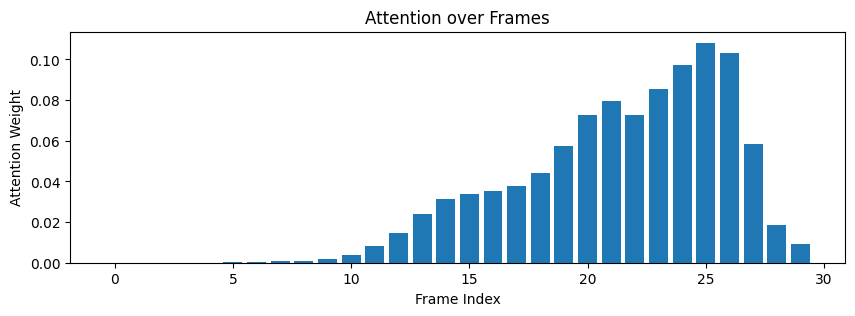

In [63]:
plt.figure(figsize=(10,3))
plt.bar(range(len(attn)), attn)
plt.title("Attention over Frames")
plt.xlabel("Frame Index")
plt.ylabel("Attention Weight")
plt.show()



In [64]:
pred_id = torch.argmax(model(X)[0]).item()
print("Predicted Sign:", labels_map[pred_id])

Predicted Sign: بيت


In [65]:
model.eval()
with torch.no_grad():
    logits, attn_weights = model(X)
    probs = torch.softmax(logits, dim=1)

pred_id = probs.argmax(dim=1).item()
confidence = probs[0, pred_id].item()

print("Predicted Sign:", labels_map[pred_id])
print(f"Confidence: {confidence:.4f}")


Predicted Sign: بيت
Confidence: 0.7395


In [66]:
topk = 5
values, indices = torch.topk(probs, topk, dim=1)

print("Top predictions:")
for i in range(topk):
    idx = indices[0, i].item()
    print(f"{i+1}. {labels_map[idx]} — {values[0, i]:.4f}")


Top predictions:
1. بيت — 0.7395
2. جار — 0.2526
3. يصعد — 0.0037
4. مشوش — 0.0015
5. ولادة — 0.0011


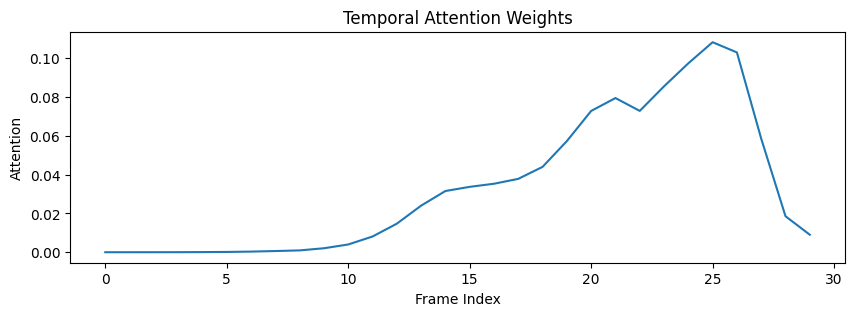

In [67]:
import matplotlib.pyplot as plt

attn = attn_weights[0].cpu().numpy()  # (T,)

plt.figure(figsize=(10, 3))
plt.plot(attn)
plt.title("Temporal Attention Weights")
plt.xlabel("Frame Index")
plt.ylabel("Attention")
plt.show()


In [68]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [69]:
model = model.to(DEVICE)

In [70]:
for X, y in test_loader:
    X = X.to(DEVICE)
    y = y.to(DEVICE)

    logits, _ = model(X)

    pred_id = logits[0].argmax().item()   # first sample
    true_id = y[0].item()

    print("True label:", labels_map[true_id])
    print("Pred label:", labels_map[pred_id])
    break


True label: بيت
Pred label: بيت


In [71]:
for X, y in test_loader:
    X = X.to(DEVICE)
    y = y.to(DEVICE)

    logits, _ = model(X)
    preds = logits.argmax(dim=1)

    for i in range(5):  # show first 5 samples
        print(f"Sample {i}")
        print("  True:", labels_map[y[i].item()])
        print("  Pred:", labels_map[preds[i].item()])
    break


Sample 0
  True: بيت
  Pred: بيت
Sample 1
  True: أب
  Pred: أب
Sample 2
  True: يشم
  Pred: يشم
Sample 3
  True: ينادي
  Pred: ينادي
Sample 4
  True: طفل
  Pred: طفل


In [72]:
probs = torch.softmax(logits, dim=1)
confidence = probs[0, pred_id].item()

print("Confidence:", round(confidence * 100, 2), "%")


Confidence: 73.95 %


In [73]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        logits, _ = model(X)
        preds = logits.argmax(dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

print("Test Accuracy:", correct / total)

Test Accuracy: 0.9772475027746947


In [74]:
print("True:", labels_map[y[0].item()])
print("Pred:", labels_map[preds[0].item()])

True: يتنامى
Pred: يتنامى


In [75]:
probs = torch.softmax(logits, dim=1)
print("Confidence:", probs[0, preds[0]].item())

Confidence: 0.9994582533836365


In [76]:
topk = torch.topk(probs[0], k=5)

print("Top-5 predictions:")
for idx, score in zip(topk.indices, topk.values):
    print(labels_map[idx.item()], f"{score.item()*100:.2f}%")

Top-5 predictions:
يتنامى 99.95%
يمشي 0.04%
طفل 0.01%
ينادي 0.00%
يسمع 0.00%


In [77]:
!pip install onnxscript onnx -q

In [79]:
import torch
import torch.onnx
import torch.nn as nn

class SignLSTM_ForONNX(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        logits, _ = self.model(x)
        return logits

DEVICE = torch.device("cpu")  # ← CPU علشان FP32

model.eval()
model_cpu = model.to(DEVICE).float()  # ← FP32

onnx_model = SignLSTM_ForONNX(model_cpu)
onnx_model.eval()

dummy_input = torch.randn(1, MAX_FRAMES, FEATURES)  # ← FP32

torch.onnx.export(
    onnx_model,
    dummy_input,
    "sign_lstm_attention_fp32.onnx",
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "logits": {0: "batch_size"}
    },
    dynamo=False
)

print("ONNX FP32 model exported!")

ONNX FP32 model exported!


/tmp/ipykernel_55/877889324.py:24: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


**######################################################################################################**

**#######################################################################################################**

#  GCN MODEL FOR SIGN LANGUAGE

# 1️⃣ Imports & Config 

In [16]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [17]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

MAX_FRAMES = 30
NUM_NODES = 42      # عدد الـ landmarks
NODE_FEATURES = 3  # (x, y, z)
NUM_CLASSES = 502

Using device: cuda


# 2️⃣ Padding + Dataset (معدل للـ GCN)

In [19]:
def pad_sequence(seq, max_len=MAX_FRAMES):
    if len(seq) >= max_len:
        return seq[:max_len]
    pad = np.zeros((max_len - len(seq), seq.shape[1]))
    return np.vstack([seq, pad])

In [20]:
class SignDataset(Dataset):
    def __init__(self, split_dir):
        self.X = []
        self.y = []

        for f in sorted(os.listdir(split_dir)):
            if f.endswith(".npz"):
                data = np.load(os.path.join(split_dir, f), allow_pickle=True)
                for seq, label in zip(data["X"], data["y"]):
                    seq = pad_sequence(seq)
                    seq = seq.reshape(MAX_FRAMES, NUM_NODES, NODE_FEATURES)
                    self.X.append(seq)
                    self.y.append(label)

        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# 3️⃣ Graph Structure (Edges)

In [21]:
HAND_EDGES = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20)
]

In [22]:
def build_adj(num_nodes, edges):
    adj = torch.eye(num_nodes)
    for i, j in edges:
        adj[i, j] = 1
        adj[j, i] = 1
    return adj

In [23]:
ADJ = build_adj(NUM_NODES, HAND_EDGES).to(DEVICE)

# 4️⃣ GCN Layer

In [24]:
class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, adj):
        # x: (B, N, F)
        x = torch.matmul(adj, x)
        return self.linear(x)

# 5️⃣ GCN Model 

In [25]:
class SignGCN_LSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.gcn1 = GCNLayer(NODE_FEATURES, 64)
        self.gcn2 = GCNLayer(64, 128)

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.fc = nn.Linear(256*2, num_classes)

    def forward(self, x, adj):
        # x: (B, T, N, F)
        B, T, N, F = x.shape

        x = x.view(B*T, N, F)
        x = torch.relu(self.gcn1(x, adj))
        x = torch.relu(self.gcn2(x, adj))

        # Pool over nodes فقط
        x = x.mean(dim=1)       # (B*T, 128)

        # رجّعي الزمن
        x = x.view(B, T, -1)    # (B, T, 128)

        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1]   # last timestep

        logits = self.fc(out)
        return logits

# 6️⃣ Load Data

In [28]:
train_ds = SignDataset("/kaggle/input/processed/train")
val_ds   = SignDataset("/kaggle/input/processed/val")
test_ds  = SignDataset("/kaggle/input/processed/test")

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)

# 7️⃣ Training Setup

In [29]:
model = SignGCN(NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 8️⃣ Training Loop

In [30]:
train_losses = []
val_accuracies = []

for epoch in range(20):
    model.train()
    total_loss = 0

    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(X, ADJ)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_losses.append(total_loss)

    # Validation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X, ADJ)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    val_accuracies.append(acc)

    print(f"Epoch {epoch+1} | Loss: {total_loss:.3f} | Val Acc: {acc:.4f}")

Epoch 1 | Loss: 1042.523 | Val Acc: 0.0561
Epoch 2 | Loss: 860.880 | Val Acc: 0.1083
Epoch 3 | Loss: 797.406 | Val Acc: 0.1349
Epoch 4 | Loss: 748.652 | Val Acc: 0.1755
Epoch 5 | Loss: 709.896 | Val Acc: 0.1777
Epoch 6 | Loss: 677.321 | Val Acc: 0.2215
Epoch 7 | Loss: 647.361 | Val Acc: 0.2460
Epoch 8 | Loss: 623.831 | Val Acc: 0.2687
Epoch 9 | Loss: 600.255 | Val Acc: 0.2915
Epoch 10 | Loss: 577.951 | Val Acc: 0.2948
Epoch 11 | Loss: 555.324 | Val Acc: 0.3254
Epoch 12 | Loss: 537.212 | Val Acc: 0.3265
Epoch 13 | Loss: 521.344 | Val Acc: 0.3570
Epoch 14 | Loss: 505.521 | Val Acc: 0.3620
Epoch 15 | Loss: 489.874 | Val Acc: 0.3809
Epoch 16 | Loss: 473.329 | Val Acc: 0.4092
Epoch 17 | Loss: 461.236 | Val Acc: 0.4259
Epoch 18 | Loss: 445.256 | Val Acc: 0.4381
Epoch 19 | Loss: 432.097 | Val Acc: 0.4559
Epoch 20 | Loss: 416.704 | Val Acc: 0.4736


# 9️⃣ Curves

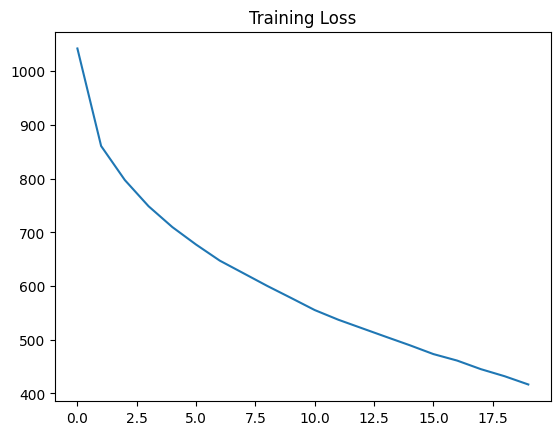

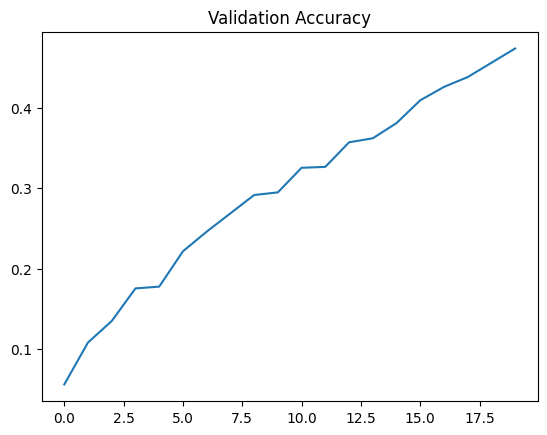

In [31]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.show()

plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.show()

# 🔟 Test Accuracy

In [32]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        logits = model(X, ADJ)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print("Test Accuracy:", correct / total)

Test Accuracy: 0.47447280799112096
